# TT compression of attention in a Molecular Transformer

This notebook examines TT compression of attention in a molecular Transformer. TT models use 20x to 53x fewer parameters, and no performance difference is detected against dense MAT on ESOL. Comparable low-rank matrix-factorization models also work, while TT has the lower mean RMSE in all four parameter brackets. Three seeds establish neither equivalence nor TT superiority.

Training results are read from committed JSON files, so the notebook runs in seconds. The commands that regenerate them are in the README.

In [ ]:
%matplotlib inline

import pandas as pd
from matplotlib import pyplot as plt

from mat_tt.data import assert_no_leakage, canonicalize_and_dedupe, featurize_molecules, make_splits
from mat_tt.model import ModelConfig, build_model, linear_inventory, parameter_report
from mat_tt.report import (
    load_payload,
    low_rank_budget_table,
    paired_difference_table,
    parameter_table,
    plot_accuracy_against_size,
    plot_learning_curve,
    plot_rank_curve,
    plot_rank_learning_curves,
    plot_training_time,
    plot_tt_error,
    probe_table,
    protocol_table,
    reference_table,
    results_path,
    tt_cost_table,
)
from mat_tt.train import load_results

## Prepare ESOL

SMILES are canonicalized and deduplicated before an 80/10/10 split. Each atom is encoded as a 26-dimensional feature vector. RDKit conformers use a fixed random seed and a versioned per-molecule cache. Labels are transformed using training-split statistics only.

In [2]:
dedup = canonicalize_and_dedupe()
features = featurize_molecules(dedup.clean_df["canonical_smiles"].tolist())
splits = make_splits(dedup.clean_df, seed=0)
assert_no_leakage(splits)

pd.DataFrame(
    {
        "value": [
            dedup.n_raw,
            len(dedup.clean_df),
            dedup.n_duplicate_groups,
            dedup.n_unparsable,
            features.n_3d,
            features.n_2d_fallback,
            len(splits.train),
            len(splits.val),
            len(splits.test),
        ]
    },
    index=[
        "raw rows",
        "unique molecules",
        "duplicate groups",
        "unparsable SMILES",
        "3D conformers",
        "2D fallbacks",
        "train",
        "validation",
        "test",
    ],
)

6 duplicate SMILES groups disagree on the label by more than 1e-06 (kept the mean; source provenance is not available).


,value
raw rows,1128
unique molecules,1117
duplicate groups,11
unparsable SMILES,0
3D conformers,1117
2D fallbacks,0
train,893
validation,112
test,112


## Dense MAT baseline

The baseline uses `d_model=256`, two encoder layers, eight heads, batch size 32, Adam, cosine decay, and early stopping. Learning rate is selected on seed 0 validation from a bracketed grid. The test split is evaluated once at the selected checkpoint.

Seeds 0, 1, and 2 control both the data split and model initialization. Models with the same seed are evaluated on the same held-out molecules. Reported spreads and error bars are sample standard deviations across these three coupled runs, not confidence intervals, and do not separate split variability from initialization variability.

Unless labeled log S, RMSE is reported in the MAT-provided standardized target units. Training-only label normalization is undone before scoring.

In [4]:
model_config = ModelConfig()
dense_model = build_model(model_config)
model_report = parameter_report(dense_model)

display(protocol_table("training"))
display(parameter_table(linear_inventory(dense_model), model_report["total_params"]))

,setting,value,how it was decided
0,d_model,256,"the case study names 128 or 256, and 256 is th..."
1,encoder layers,2,the case study suggests 2 to 3
2,attention heads,8,MAT's default
3,dropout,0.1,MAT's default
4,distance kernel,softmax,"changed from MAT's default, see the note below"
5,batch size,32,the case study suggests 16 to 32
6,epoch cap,150,"our choice, a cap early stopping rarely reaches"
7,early stopping patience,25,our choice
8,gradient clip,5.0,MAT's default
9,weight decay,0.0,"our choice, none"


,role,layers,shape,params,share
0,feed_forward,4,256 x 256,263168,32.9%
1,W_Q,2,256 x 256,131584,16.5%
2,W_K,2,256 x 256,131584,16.5%
3,W_V,2,256 x 256,131584,16.5%
4,W_O,2,256 x 256,131584,16.5%
5,embedding,1,26 x 256,6912,0.9%
6,output_head,1,256 x 1,257,0.0%


In [53]:
baseline = load_results(results_path("task2_dense_baseline.json"))
dense_payload = load_payload("task2_dense_baseline")
runs = baseline["runs"]

references = reference_table(runs)
references.loc[len(references)] = {
    "reference": "dense MAT, this study",
    "test RMSE": (
        f"{dense_payload['summary']['test_rmse_mean']:.3f} +/- "
        f"{dense_payload['summary']['test_rmse_std']:.3f}"
    ),
    "note": "mean +/- SD across three coupled split-and-initialization runs",
}
display(references)

,reference,test RMSE,note
0,predict the training mean,0.987 +/- 0.060,training mean per seed; range 0.953 to 1.056
1,MAT from scratch (paper),0.285 +/- 0.022,"large hyperparameter search, orientation only"
2,"dense MAT, this study",0.314 +/- 0.022,mean +/- SD across three coupled split-and-ini...


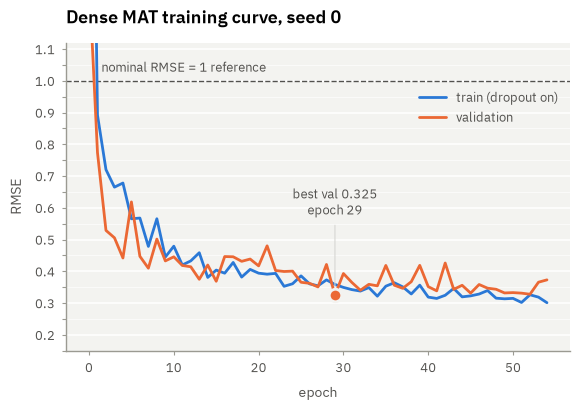

In [42]:
plot_learning_curve(runs[0])
plt.show()

The dense model improves on predicting the training mean, but remains above the paper's orientation benchmark in RMSE. The curve shows only seed 0, so the three-run mean and spread in the table are the reference for the compression comparisons.

## Do trained weights fit TT?

The primary compression target is the 12 square $256 \times 256$ matrices in the two MAT encoders: eight attention projections ($W_Q$, $W_K$, $W_V$, and $W_O$ in each encoder) and four feed-forward matrices (two per encoder). These layers hold 789,504 of 799,233 parameters (98.8%), so targeting them gives the highest whole-model compression. The embedding, normalization layers, and 256-to-1 output projection remain dense.

TT stores a reshaped weight matrix as a chain of small core tensors. The TT rank sets the sizes of the connections between cores, controlling storage and flexibility. Here the row and column dimensions of each square weight matrix use a $4 \times 4 \times 4 \times 4$ factorization.

The dense matrix $W$ is approximated by a TT matrix $\hat{W}$. The plot's y-axis is the relative reconstruction error $\lVert W - \hat{W} \rVert_F / \lVert W \rVert_F$: $0$ is a perfect reconstruction and a value near $1$ captures little of the original matrix. The table gives storage costs, and truncated SVD is included at a matched parameter budget.

,TT rank,cores,dense,ratio,all 12 matrices
0,2,192,"65,536",341x,"2,304"
1,4,640,"65,536",102x,"7,680"
2,8,"2,304","65,536",28x,"27,648"
3,16,"8,704","65,536",8x,"104,448"


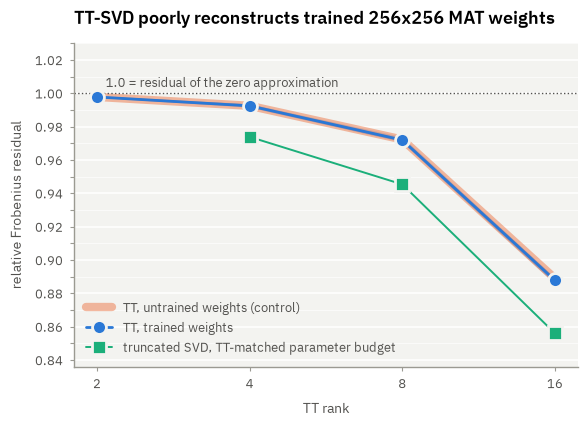

In [54]:
weight_analysis = load_payload("task3_weight_analysis")
display(tt_cost_table(weight_analysis))
plot_tt_error(weight_analysis)
plt.show()

Truncated SVD is the best Frobenius-norm approximation at a chosen matrix rank (Eckart-Young-Mirsky theorem). Its lower error at a similar storage budget indicates that these trained weights do not naturally fit this TT factorization. Reconstruction error alone does not determine predictive performance after training under the TT constraint.

## Replace, train, and compare

Truncated SVD reconstructs the trained square weights better than TT-SVD. The predictive question is therefore whether TT structure helps beyond pure reconstruction. In what follows, both TT-constrained and low-rank matrix-constrained models are trained on the same splits as the dense baseline, in both a finetuning setting (departing from the dense baseline) as well as from scratch, for different ranks.

In [46]:
scratch = load_payload("task4_tt_scratch_per_rank_lr")
shared_rate = load_payload("task4_tt_scratch")
fine_tuned = load_payload("task4_tt_finetune")
low_rank_scratch = load_payload("task7_low_rank_scratch")
low_rank_fine_tuned = load_payload("task7_low_rank_finetune")
probes = load_payload("task4_probes")
forest = load_payload("task7_random_forest")

### Optimization diagnostic

Does a shared learning rate give a fair comparison across TT ranks? The table below records the original shared-rate sweep, which selected one scratch learning rate across ranks and a separate fine-tuning learning rate on seed 0 validation. The curves compare that scratch protocol with a later sweep that selects the scratch learning rate separately for each rank, again using seed 0 validation. Test scores are not used for either selection.

,setting,value,how it was decided
0,TT modes,4 x 4 x 4 x 4,the case study's suggested 4x4x4x4 for d_model...
1,TT ranks,"2, 4, 8","the case study suggests 2, 4, 8"
2,"learning rate, TT scratch",1e-02,"swept over 3e-04, 1e-03, 3e-03, 1e-02, 3e-02, ..."
3,"learning rate, TT finetune",3e-03,"swept over 1e-04, 3e-04, 1e-03, 3e-03, 1e-02; ..."


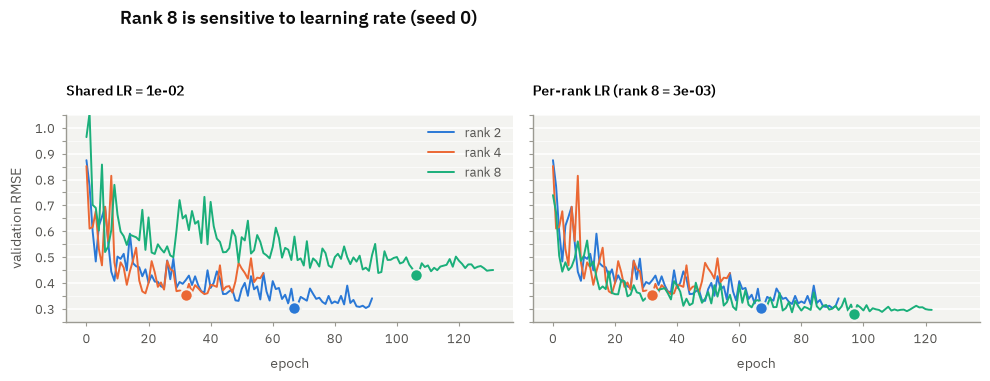

In [48]:
display(protocol_table("tt"))
plot_rank_learning_curves([shared_rate, scratch])
plt.show()

The poor rank-8 validation result under the shared learning rate improves after per-rank tuning. The following comparisons therefore use the tuned scratch protocol. A rank comparison under one shared learning rate would mix representation and optimization effects.

### Comparable parameter budgets

The table below uses actual whole-model parameter counts. Uniform matrix rank changes the model by 6,144 parameters at a time, so exact matching is impossible. Matrix ranks 1 and 2 bracket TT rank 4, while matrix ranks 4 and 5 bracket TT rank 8. The comparison below shows both measured neighbors, without interpolating an unmeasured score.

In [49]:
display(low_rank_budget_table(scratch, low_rank_scratch))

,lower matrix rank,lower params,TT rank,TT params,upper matrix rank,upper params,lower difference,upper difference
0,1,"18,945",4,"20,481",2,"25,089",-7.5%,+22.5%
1,4,"37,377",8,"40,449",5,"43,521",-7.6%,+7.6%


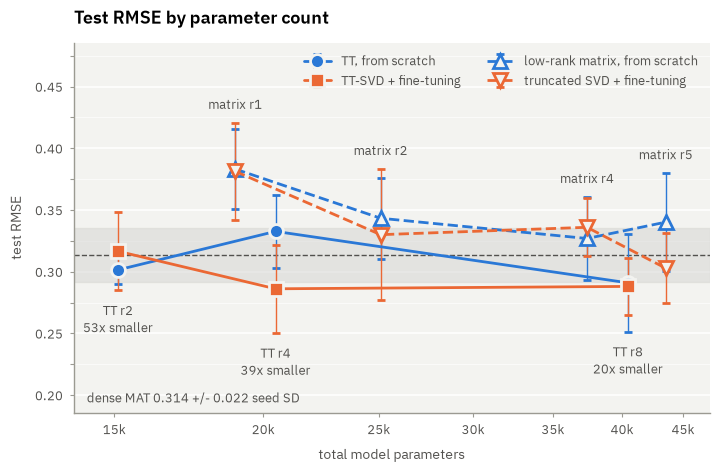

In [32]:
plot_rank_curve(
    [scratch, fine_tuned],
    dense_payload,
    low_rank_payloads=[low_rank_scratch, low_rank_fine_tuned],
)
plt.show()

This is the direct TT versus low-rank matrix comparison. The means favor TT in all four bracketing cases, but most one-SD bars overlap. Three seeds do not establish a TT-specific advantage.

The table below compares each TT variant with dense MAT on the same held-out molecules for each seed. Negative differences favor TT. Its spread is the sample SD of three coupled split-and-initialization differences, not a confidence interval or a test of equivalence.

In [50]:
display(paired_difference_table([scratch, fine_tuned], baseline))

,model,TT rank,mean difference from dense,spread of differences,worst single seed
0,"TT trained from scratch, LR tuned per rank",2,-0.0122,0.0201,-0.0258
1,"TT trained from scratch, LR tuned per rank",4,0.0190,0.0136,0.0326
2,"TT trained from scratch, LR tuned per rank",8,-0.0226,0.0288,-0.0558
3,TT-SVD + fine-tuning,2,0.0030,0.0329,0.0361
4,TT-SVD + fine-tuning,4,-0.0275,0.0343,-0.0641
5,TT-SVD + fine-tuning,8,-0.0255,0.0146,-0.0411


### Broader controls

Target-set probes ask which MAT matrices matter for compression. A random forest with 12 molecular descriptors asks whether ESOL requires a Transformer at all. The overview places these controls alongside the TT and low-rank models already compared. Filled markers are trained from scratch. Hollow markers start from dense decompositions and include dense pretraining.

In [9]:
display(probe_table(probes, shared_rate))
pd.DataFrame(
    [
        {
            "model": "random forest, 12 descriptors",
            "test RMSE": (
                f"{forest['summary']['test_rmse_mean']:.3f} +/- "
                f"{forest['summary']['test_rmse_std']:.3f}"
            ),
            "fit seconds/seed": round(forest["summary"]["train_seconds_mean"], 1),
        },
        {
            "model": "dense MAT",
            "test RMSE": (
                f"{dense_payload['summary']['test_rmse_mean']:.3f} +/- "
                f"{dense_payload['summary']['test_rmse_std']:.3f}"
            ),
            "fit seconds/seed": round(dense_payload["summary"]["train_seconds_mean"], 1),
        },
    ]
)

,target set,layers,total params,compression,test RMSE
0,the 12 square matrices,12,"20,481",39x,0.333 +/- 0.030
1,"attention only, 8 layers",8,"280,065",3x,0.372 +/- 0.084
2,the 12 square matrices plus the embedding,13,"14,785",54x,0.358 +/- 0.043


,model,test RMSE,fit seconds/seed
0,"random forest, 12 descriptors",0.322 +/- 0.033,1.2
1,dense MAT,0.314 +/- 0.022,104.2


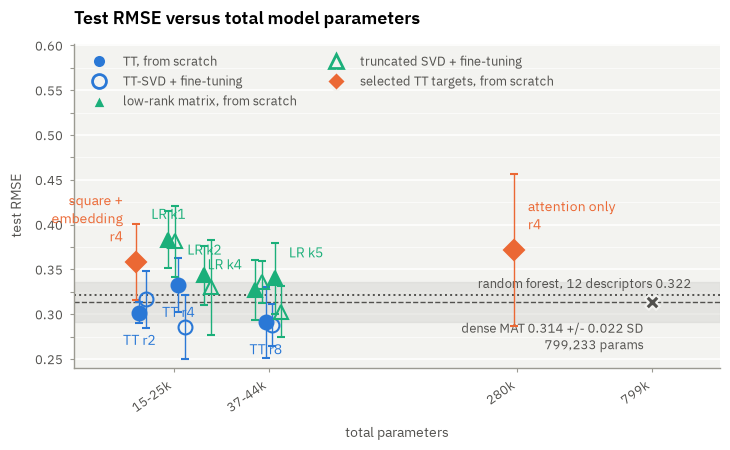

In [39]:
plot_accuracy_against_size(
    [scratch, fine_tuned],
    dense_payload,
    probes=probes,
    low_rank_payloads=[low_rank_scratch, low_rank_fine_tuned],
    forest=forest,
)
plt.show()

The random forest nearly reaches dense MAT, so ESOL does not show that the Transformer needs its full capacity.

### Training cost

Does the parameter reduction also reduce CPU training time? This comparison separates training from scratch and fine-tuning, whose full cost includes dense pretraining.

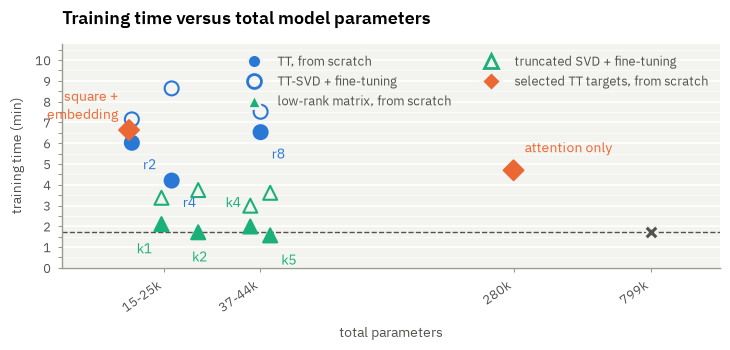

In [40]:
plot_training_time(
    [scratch, fine_tuned],
    dense_payload,
    probes=probes,
    low_rank_payloads=[low_rank_scratch, low_rank_fine_tuned],
)
plt.show()

Storage compression is not CPU training acceleration in this model. Fine-tuning also includes dense pretraining, so their times are not directly comparable with scratch training alone.

## Duplicate-label irreducible-error estimate

The six duplicate molecules with conflicting ESOL labels give a small, auditable estimate of label uncertainty. If each pair is an independent repeat measurement of the same latent solubility with identically distributed, zero-mean noise, its difference $d_i$ has variance $2\sigma^2$. We therefore estimate the irreducible RMSE of a fresh label as $\hat{\sigma}=\sqrt{\sum_i d_i^2/(2n)}$ for $n=6$ pairs.

In [ ]:
from math import sqrt

from mat_tt.report import LOGS_PER_STANDARDIZED_UNIT, PAPER_RMSE

deduplication = canonicalize_and_dedupe()
duplicate_groups = deduplication.disagreeing_duplicate_groups
assert len(duplicate_groups) == 6
assert all(len(labels) == 2 for _, labels in duplicate_groups)

duplicate_pairs = pd.DataFrame(
    [
        {
            "canonical SMILES": smiles,
            "label 1": labels[0],
            "label 2": labels[1],
            "difference": labels[1] - labels[0],
            "absolute difference": abs(labels[1] - labels[0]),
        }
        for smiles, labels in duplicate_groups
    ]
)
display(duplicate_pairs)

pair_differences = duplicate_pairs["difference"]
duplicate_noise_rmse = sqrt((pair_differences**2).sum() / (2 * len(pair_differences)))
duplicate_noise_log_s = duplicate_noise_rmse * LOGS_PER_STANDARDIZED_UNIT
dense_log_s = dense_payload["summary"]["test_rmse_mean"] * LOGS_PER_STANDARDIZED_UNIT
paper_log_s = PAPER_RMSE * LOGS_PER_STANDARDIZED_UNIT

display(
    pd.DataFrame(
        [
            {
                "conflicting duplicate pairs": len(duplicate_pairs),
                "duplicate-label estimate (standardized RMSE)": duplicate_noise_rmse,
                "duplicate-label estimate (log S)": duplicate_noise_log_s,
                "Delaney benchmark (log S)": paper_log_s,
                "dense MAT (log S)": dense_log_s,
            }
        ]
    ).round(3)
)

6 duplicate SMILES groups disagree on the label by more than 1e-06 (kept the mean; source provenance is not available).


,canonical SMILES,label 1,label 2,difference,absolute difference
0,CC12CCC(CC1)C(C)(C)O2,0.672915,0.625194,-0.047721,0.047721
1,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,-0.529655,-0.645140,-0.115485,0.115485
2,CCC1(C(C)C)C(=O)NC(=O)NC1=O,0.400905,0.430492,0.029587,0.029587
3,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,0.277785,0.187115,-0.090670,0.090670
4,Cc1ncc([N+](=O)[O-])n1CCO,0.873344,0.854255,-0.019088,0.019088
5,OCC(O)C(O)C(O)C(O)CO,1.484173,1.975700,0.491527,0.491527


,conflicting duplicate pairs,duplicate-label estimate (standardized RMSE),duplicate-label estimate (log S),Delaney benchmark (log S),dense MAT (log S)
0,6,0.149,0.312,0.597,0.657


The calculation is an attempt to quantify label uncertainty from the evidence available. It gives $0.312$ log S, about half of Delaney's published $0.597$ log S benchmark (Delaney, 2004, [DOI 10.1021/ci034243x](https://doi.org/10.1021/ci034243x)) and below this dense MAT result of $0.657$ log S. It does not assign the remaining gap to model error: six pairs are too few for a precise estimate, their provenance and independence are unknown, and they may not represent the test-set population. Published reproducibility estimates for literature-compiled solubility data are around $0.6$ to $0.7$ log S (Palmer and Mitchell, 2014, [DOI 10.1021/mp500103r](https://doi.org/10.1021/mp500103r)).

## Conclusion

- TT uses 20x to 53x fewer stored parameters, with no predictive difference from dense MAT detected in three runs. This is not evidence of equivalence. Low-rank matrix models also retain useful prediction at 18x to 42x compression. TT has lower mean RMSE in all four budget brackets, but three seeds do not establish superiority.
- TT-SVD reconstructs the trained weights poorly, yet TT-constrained models can be trained successfully. Rank and learning rate interact, so validation-based tuning is part of the comparison.
- Parameter savings do not translate into faster CPU training here, and fine-tuned paths include dense pretraining. The random forest result makes ESOL a weak capacity benchmark. The six conflicting label pairs provide only a conditional uncertainty estimate, not a confirmed dataset-wide noise floor.